# Chapter 1 — The Machine Learning Landscape

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from packaging.version import Version

# Scikit-Learn
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn import preprocessing, pipeline

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

# Matplotlib defaults (book style)
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Quick sanity checks
assert sys.version_info >= (3, 10), "Python 3.10+ required"
assert Version(sklearn.__version__) >= Version("1.5"), f"sklearn >= 1.5 required, got {sklearn.__version__}"
print(f"Python   {sys.version.split()[0]}")
print(f"sklearn  {sklearn.__version__}")
print(f"numpy    {np.__version__}")
print(f"pandas   {pd.__version__}")
print(f"polars   {pl.__version__}")


Python   3.12.12
sklearn  1.8.0
numpy    2.4.2
pandas   3.0.0
polars   1.34.0


## Code Example 1-1 — Life Satisfaction vs GDP per capita

Ejemplo clave del capítulo: entrenamos dos modelos (LinearRegression y KNeighborsRegressor) para predecir satisfacción de vida dado el GDP per cápita.

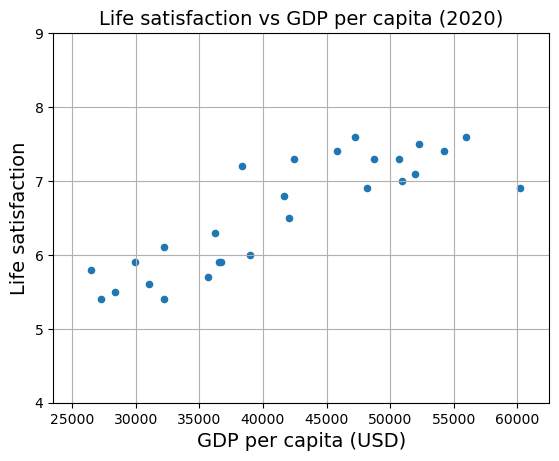

In [2]:
# Load data from local data/ folder (downloaded in setup)
lifesat = pd.read_csv(DATA_PATH / "lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.title("Life satisfaction vs GDP per capita (2020)")
plt.show()


In [3]:
# ── Linear Regression model ────────────────────────────────
model_lr = LinearRegression()
model_lr.fit(X, y)

# Prediction for Puerto Rico (GDP per capita ~33,442 USD in 2020)
X_new = [[33_442.8]]
pred_lr = model_lr.predict(X_new)
print(f"LinearRegression → predicted life satisfaction: {pred_lr[0][0]:.4f}")


LinearRegression → predicted life satisfaction: 6.0161


In [4]:
# ── k-Nearest Neighbors (k=3) model ───────────────────────
model_knn = KNeighborsRegressor(n_neighbors=3)
model_knn.fit(X, y)

pred_knn = model_knn.predict(X_new)
print(f"KNeighborsRegressor(k=3) → predicted life satisfaction: {pred_knn[0][0]:.4f}")

# Compare both
print(f"\nLinearRegression : {pred_lr[0][0]:.4f}")
print(f"KNN (k=3)        : {pred_knn[0][0]:.4f}")


KNeighborsRegressor(k=3) → predicted life satisfaction: 5.7333

LinearRegression : 6.0161
KNN (k=3)        : 5.7333


## Exploración de datos con Polars

Mismos datos, usando la API Polars (más rápida para ETL):


In [5]:
# Cargar lifesat con Polars
df_lifesat = pl.read_csv(DATA_PATH / "lifesat.csv")
print(df_lifesat.describe())
df_lifesat


shape: (9, 4)
┌────────────┬───────────────┬──────────────────────┬───────────────────┐
│ statistic  ┆ Country       ┆ GDP per capita (USD) ┆ Life satisfaction │
│ ---        ┆ ---           ┆ ---                  ┆ ---               │
│ str        ┆ str           ┆ f64                  ┆ f64               │
╞════════════╪═══════════════╪══════════════════════╪═══════════════════╡
│ count      ┆ 27            ┆ 27.0                 ┆ 27.0              │
│ null_count ┆ 0             ┆ 0.0                  ┆ 0.0               │
│ mean       ┆ null          ┆ 41564.521771         ┆ 6.566667          │
│ std        ┆ null          ┆ 9631.452319          ┆ 0.765607          │
│ min        ┆ Australia     ┆ 26456.387938         ┆ 5.4               │
│ 25%        ┆ null          ┆ 35638.421351         ┆ 5.9               │
│ 50%        ┆ null          ┆ 41627.129269         ┆ 6.8               │
│ 75%        ┆ null          ┆ 50683.32351          ┆ 7.3               │
│ max        ┆ United St

Country,GDP per capita (USD),Life satisfaction
str,f64,f64
"""Russia""",26456.387938,5.8
"""Greece""",27287.083401,5.4
"""Turkey""",28384.987785,5.5
"""Latvia""",29932.49391,5.9
"""Hungary""",31007.768407,5.6
…,…,…
"""Austria""",51935.603862,7.1
"""Iceland""",52279.728851,7.5
"""Netherlands""",54209.563836,7.4


In [6]:
# Dataset completo (incluyendo países atípicos fuera del rango 23k-62k USD)
df_full = pl.read_csv(DATA_PATH / "lifesat_full.csv")

# Países con GDP < 23,500 o > 62,500 (los que el libro "oculta" para no hacer overfitting obvio)
outliers = df_full.filter(
    (pl.col("GDP per capita (USD)") < 23_500) | (pl.col("GDP per capita (USD)") > 62_500)
)
print(f"Países fuera del rango: {len(outliers)}")
outliers


Países fuera del rango: 9


Country,GDP per capita (USD),Life satisfaction
str,f64,f64
"""South Africa""",11466.189672,4.7
"""Colombia""",13441.492952,6.3
"""Brazil""",14063.982505,6.4
"""Mexico""",17887.750736,6.5
"""Chile""",23324.524751,6.5
"""Norway""",63585.903514,7.6
"""Switzerland""",68393.306004,7.5
"""Ireland""",89688.956958,7.0
"""Luxembourg""",110261.157353,6.9


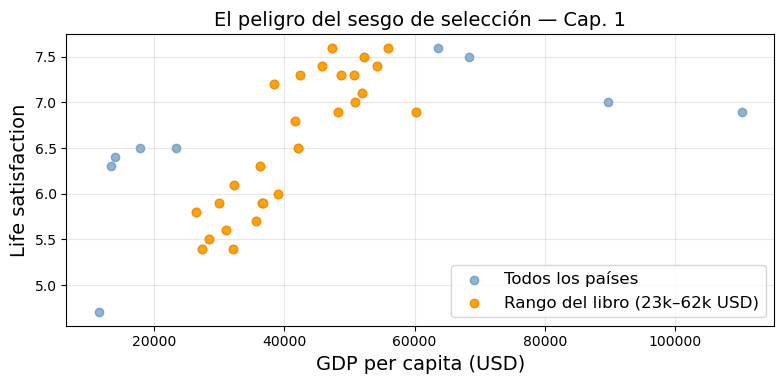

In [7]:
# Visualización: dataset completo vs rango del libro
# Ilustra cómo la relación lineal falla fuera del rango seleccionado
df_full_pd = df_full.to_pandas()

fig, ax = plt.subplots(figsize=(8, 4))

# Rango completo
ax.scatter(df_full_pd["GDP per capita (USD)"],
           df_full_pd["Life satisfaction"],
           color="steelblue", alpha=0.6, label="Todos los países")

# Resaltar rango del libro (23k–62k)
mask = (df_full_pd["GDP per capita (USD)"] >= 23_500) & (df_full_pd["GDP per capita (USD)"] <= 62_500)
ax.scatter(df_full_pd[mask]["GDP per capita (USD)"],
           df_full_pd[mask]["Life satisfaction"],
           color="orange", edgecolors="darkorange", zorder=3, label="Rango del libro (23k–62k USD)")

ax.set_xlabel("GDP per capita (USD)")
ax.set_ylabel("Life satisfaction")
ax.set_title("El peligro del sesgo de selección — Cap. 1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
